In [4]:
# profile_lsesn.py
import cProfile
import pstats
import io

# Import everything from your v2 script except the grid loop
# (or just paste the relevant parts: LSESN class, evaluate function, data loading)

def profile_workload():
    """Run a small representative workload."""
    # Pick 3 configs that span the parameter space
    test_configs = [
        {
            "normalization": "zscore", "train_warmup": 500, "test_warmup": 500,
            "units": 1000, "reservoir_connectivity": 0.1, "sr": 0.95,
            "lr_long": 0.15, "lr_typ": 0.4, "lr_short": 0.8,
            "input_scaling": 1.0, "regression": 1e-6,
            "k": 4, "m": 2, "noise_sigma": 0.005,
        },
        {
            "normalization": "zscore", "train_warmup": 500, "test_warmup": 500,
            "units": 2000, "reservoir_connectivity": 0.1, "sr": 0.95,
            "lr_long": 0.15, "lr_typ": 0.4, "lr_short": 0.8,
            "input_scaling": 1.0, "regression": 1e-6,
            "k": 4, "m": 2, "noise_sigma": 0.005,
        },
        {
            "normalization": "zscore", "train_warmup": 500, "test_warmup": 500,
            "units": 1000, "reservoir_connectivity": 0.1, "sr": 0.95,
            "lr_long": 0.15, "lr_typ": 0.4, "lr_short": 0.8,
            "input_scaling": 1.0, "regression": 1e-6,
            "k": 4, "m": 4, "noise_sigma": 0.005,  # m=4 to see short-term cost
        },
    ]
    for params in test_configs:
        evaluate_lsesn_one_seed(params, seed=42)


# Run with cProfile
profiler = cProfile.Profile()
profiler.enable()
profile_workload()
profiler.disable()

# Print results sorted by cumulative time
stream = io.StringIO()
stats = pstats.Stats(profiler, stream=stream).sort_stats("cumulative")
stats.print_stats(30)  # top 30 functions by cumulative time
print(stream.getvalue())

# Also save raw stats so you can re-analyze without re-running
profiler.dump_stats("lsesn_profile.prof")

         525080 function calls (523676 primitive calls) in 5970.200 seconds

   Ordered by: cumulative time
   List reduced from 357 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1231    0.355    0.000 12968.946   10.535 /opt/anaconda3/lib/python3.13/asyncio/base_events.py:1962(_run_once)
1231/1213   13.999    0.011 10029.860    8.269 /opt/anaconda3/lib/python3.13/selectors.py:540(select)
   303992 5333.317    0.018 5333.317    0.018 /var/folders/p_/j__hv0j95yv8xknt5_nvt4pw0000gn/T/ipykernel_13167/646679647.py:139(_step)
     5937  575.107    0.097 1729.038    0.291 {built-in method time.sleep}
        1    0.003    0.003  164.059  164.059 /var/folders/p_/j__hv0j95yv8xknt5_nvt4pw0000gn/T/ipykernel_13167/1444437490.py:9(profile_workload)
        9    0.084    0.009   41.267    4.585 /var/folders/p_/j__hv0j95yv8xknt5_nvt4pw0000gn/T/ipykernel_13167/646679647.py:66(init_reservoir_weights)
        3    0.069    0.023   17.723    

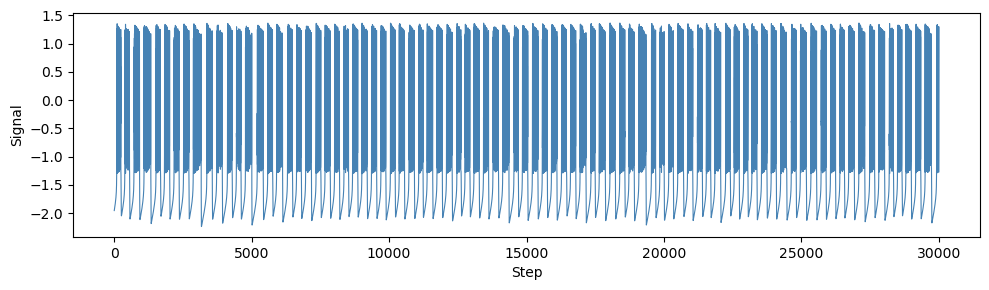

Total combinations: 3072
Total trials with 3 seeds: 9216
[20/3072]  elapsed: 1389s  current best score: 0.092941
[40/3072]  elapsed: 4221s  current best score: 0.092941
[60/3072]  elapsed: 6167s  current best score: 0.087818
[80/3072]  elapsed: 7099s  current best score: 0.087818
[100/3072]  elapsed: 8054s  current best score: 0.087818
[120/3072]  elapsed: 8967s  current best score: 0.087818
[140/3072]  elapsed: 9894s  current best score: 0.087818
[160/3072]  elapsed: 10820s  current best score: 0.021811
[180/3072]  elapsed: 11769s  current best score: 0.021811
[200/3072]  elapsed: 12669s  current best score: 0.021811
[220/3072]  elapsed: 13594s  current best score: 0.021811
[240/3072]  elapsed: 14473s  current best score: 0.021811
[260/3072]  elapsed: 15404s  current best score: 0.021811
[280/3072]  elapsed: 16309s  current best score: 0.021811
[300/3072]  elapsed: 17218s  current best score: 0.021811
[320/3072]  elapsed: 18110s  current best score: 0.021811
[340/3072]  elapsed: 19007

KeyboardInterrupt: 

In [2]:
"""
LS-ESN v2 for Rulkov map closed-loop prediction.

Changes from v1:
  1. Composite metric: short-horizon NRMSE (50 steps) + spike-count penalty
  2. Longer training: 20,000 points
  3. Larger reservoir: up to N=2000 per branch (3N total state)
  4. Training noise injection on inputs
  5. Seed averaging (3 seeds per config)
  6. Per-reservoir leak rates (long slow, typical medium, short fast)
  7. Short-term reservoir re-init: zeros instead of standard-normal
     (removes per-step stochasticity that harms closed-loop stability)
"""

import itertools
import time
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# SCALERS
# ==========================================================
def fit_scaler(X, method="zscore"):
    X = np.asarray(X)
    if method == "none":
        return {"method": "none"}
    if method == "zscore":
        return {"method": "zscore", "mu": X.mean(axis=0), "sd": X.std(axis=0) + 1e-12}
    if method == "minmax01":
        return {"method": "minmax01", "lo": X.min(axis=0), "hi": X.max(axis=0)}
    if method == "minmax11":
        return {"method": "minmax11", "lo": X.min(axis=0), "hi": X.max(axis=0)}
    raise ValueError(method)


def transform_array(X, scaler):
    X = np.asarray(X)
    m = scaler["method"]
    if m == "none":
        return X.copy()
    if m == "zscore":
        return (X - scaler["mu"]) / scaler["sd"]
    if m == "minmax01":
        return (X - scaler["lo"]) / (scaler["hi"] - scaler["lo"] + 1e-12)
    if m == "minmax11":
        return 2.0 * (X - scaler["lo"]) / (scaler["hi"] - scaler["lo"] + 1e-12) - 1.0


def inverse_transform_array(X, scaler):
    X = np.asarray(X)
    m = scaler["method"]
    if m == "none":
        return X.copy()
    if m == "zscore":
        return X * scaler["sd"] + scaler["mu"]
    if m == "minmax01":
        return X * (scaler["hi"] - scaler["lo"]) + scaler["lo"]
    if m == "minmax11":
        return (X + 1.0) / 2.0 * (scaler["hi"] - scaler["lo"]) + scaler["lo"]


# ==========================================================
# RESERVOIR WEIGHT INITIALIZATION
# ==========================================================
def init_reservoir_weights(N, D, sr, input_scaling, connectivity, rng):
    W = rng.uniform(-0.5, 0.5, size=(N, N))
    mask = rng.uniform(0.0, 1.0, size=(N, N)) < connectivity
    W = W * mask
    eigs = np.linalg.eigvals(W)
    rho = np.max(np.abs(eigs))
    if rho > 0:
        W = W * (sr / rho)
    Win = rng.uniform(-input_scaling, input_scaling, size=(N, D))
    bias = rng.uniform(-0.5, 0.5, size=(N,))
    return W, Win, bias


# ==========================================================
# LS-ESN with per-reservoir leak rates
# ==========================================================
class LSESN:
    """
    Three reservoirs with distinct leak rates:
      - long:    slow integration (low lr)
      - typical: medium
      - short:   fast response (high lr)

    Short-term reservoir uses ZEROS init for x(t-m) instead of standard
    normal (paper's version). This removes per-step stochasticity that
    destabilizes closed-loop rollout. The "memory erasure" property is
    preserved since x(t-m) is still reset at every step.
    """

    def __init__(
        self,
        N=1000,
        D=1,
        sr=0.95,
        lr_long=0.15,
        lr_typ=0.4,
        lr_short=0.8,
        input_scaling=1.0,
        connectivity=0.1,
        k=4,
        m=2,
        ridge=1e-6,
        noise_sigma=0.005,   # Gaussian noise std on inputs during training
        seed=42,
    ):
        self.N = N
        self.D = D
        self.sr = sr
        self.lr_long = lr_long
        self.lr_typ = lr_typ
        self.lr_short = lr_short
        self.input_scaling = input_scaling
        self.connectivity = connectivity
        self.k = int(k)
        self.m = int(m)
        self.ridge = ridge
        self.noise_sigma = noise_sigma
        self.seed = seed

        rng = np.random.default_rng(seed)
        self.W_long, self.Win_long, self.b_long = init_reservoir_weights(
            N, D, sr, input_scaling, connectivity, rng
        )
        self.W_typ, self.Win_typ, self.b_typ = init_reservoir_weights(
            N, D, sr, input_scaling, connectivity, rng
        )
        self.W_short, self.Win_short, self.b_short = init_reservoir_weights(
            N, D, sr, input_scaling, connectivity, rng
        )

        self.rng_noise = np.random.default_rng(seed + 100)
        self.Wout = None

    @staticmethod
    def _step(x_prev, u, W, Win, bias, lr):
        pre = Win @ u + W @ x_prev + bias
        return (1.0 - lr) * x_prev + lr * np.tanh(pre)

    def _long_state_sequence(self, U):
        T = len(U)
        X = np.zeros((T, self.N))
        x = np.zeros(self.N)
        for t in range(T):
            if t < self.k:
                x = self._step(x, U[t], self.W_long, self.Win_long, self.b_long, self.lr_long)
                X[t] = x
            else:
                x_prev = X[t - self.k]
                x = self._step(x_prev, U[t], self.W_long, self.Win_long, self.b_long, self.lr_long)
                X[t] = x
        return X

    def _typical_state_sequence(self, U):
        T = len(U)
        X = np.zeros((T, self.N))
        x = np.zeros(self.N)
        for t in range(T):
            x = self._step(x, U[t], self.W_typ, self.Win_typ, self.b_typ, self.lr_typ)
            X[t] = x
        return X

    def _short_state_sequence(self, U):
        """Zeros-init version: deterministic, stable for closed loop."""
        T = len(U)
        X = np.zeros((T, self.N))
        m = self.m
        for t in range(T):
            x = np.zeros(self.N)  # <-- zeros init, was rng.standard_normal
            start = max(0, t - m + 1)
            for s in range(start, t + 1):
                x = self._step(x, U[s], self.W_short, self.Win_short, self.b_short, self.lr_short)
            X[t] = x
        return X

    def _collect_states(self, U):
        X_long = self._long_state_sequence(U)
        X_typ = self._typical_state_sequence(U)
        X_short = self._short_state_sequence(U)
        return np.concatenate([X_long, X_typ, X_short], axis=1)

    def fit(self, U, Y, warmup=500):
        U = np.asarray(U, dtype=float)
        Y = np.asarray(Y, dtype=float)

        # Inject Gaussian noise on inputs ONLY (targets stay clean)
        if self.noise_sigma > 0:
            U_noisy = U + self.noise_sigma * self.rng_noise.standard_normal(U.shape)
        else:
            U_noisy = U

        X = self._collect_states(U_noisy)
        X_use = X[warmup:]
        Y_use = Y[warmup:]

        XtX = X_use.T @ X_use
        reg = self.ridge * np.eye(XtX.shape[0])
        XtY = X_use.T @ Y_use
        self.Wout = np.linalg.solve(XtX + reg, XtY).T

    def closed_loop(self, U_warmup, n_steps):
        assert self.Wout is not None, "Call fit() first."

        T_w = len(U_warmup)
        x_long_hist = np.zeros((T_w, self.N))
        x = np.zeros(self.N)
        for t in range(T_w):
            if t < self.k:
                x = self._step(x, U_warmup[t], self.W_long, self.Win_long, self.b_long, self.lr_long)
            else:
                x = self._step(x_long_hist[t - self.k], U_warmup[t],
                               self.W_long, self.Win_long, self.b_long, self.lr_long)
            x_long_hist[t] = x

        x_typ = np.zeros(self.N)
        for t in range(T_w):
            x_typ = self._step(x_typ, U_warmup[t], self.W_typ, self.Win_typ, self.b_typ, self.lr_typ)

        u_buffer = list(U_warmup[-(self.m - 1):]) if self.m > 1 else []

        preds = np.zeros((n_steps, self.D))
        x_long_roll = list(x_long_hist[-self.k:])
        u_t = U_warmup[-1].copy()

        for step in range(n_steps):
            x_prev_long = x_long_roll[0]
            x_long_new = self._step(x_prev_long, u_t,
                                    self.W_long, self.Win_long, self.b_long, self.lr_long)
            x_long_roll.append(x_long_new)
            x_long_roll.pop(0)

            x_typ = self._step(x_typ, u_t, self.W_typ, self.Win_typ, self.b_typ, self.lr_typ)

            x_s = np.zeros(self.N)  # zeros init
            recent = u_buffer + [u_t]
            recent = recent[-self.m:]
            for u_past in recent:
                x_s = self._step(x_s, u_past, self.W_short, self.Win_short, self.b_short, self.lr_short)

            state = np.concatenate([x_long_new, x_typ, x_s])
            y_hat = self.Wout @ state
            preds[step] = y_hat

            u_buffer.append(u_t)
            if len(u_buffer) > self.m:
                u_buffer.pop(0)
            u_t = y_hat.copy()

        return preds


# ==========================================================
# COMPOSITE METRIC
# ==========================================================
def count_spikes(signal, threshold=0.0):
    """Count local maxima above threshold. Simple spike detector for Rulkov."""
    s = np.asarray(signal).ravel()
    if len(s) < 3:
        return 0
    is_peak = (s[1:-1] > s[:-2]) & (s[1:-1] > s[2:]) & (s[1:-1] > threshold)
    return int(np.sum(is_peak))


def composite_score(y_true, y_pred, short_horizon=50, alpha=0.5, threshold=0.0):
    """
    score = NRMSE_short + alpha * |log(spike_ratio)|

    - NRMSE_short: NRMSE over first `short_horizon` steps (tracking quality)
    - spike-count penalty: full-rollout spike count ratio in log space
      (symmetric: penalizes both over- and under-prediction, including
      the flat-line failure mode)
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # Short-horizon NRMSE
    h = min(short_horizon, len(y_true))
    err = y_true[:h] - y_pred[:h]
    rmse = np.sqrt(np.mean(err ** 2))
    denom = np.std(y_true[:h])
    nrmse_short = rmse / denom if denom > 0 else np.inf

    # Spike count ratio (full rollout)
    n_true = count_spikes(y_true, threshold=threshold)
    n_pred = count_spikes(y_pred, threshold=threshold)
    if n_true == 0:
        spike_pen = 0.0 if n_pred == 0 else 5.0
    else:
        ratio = max(n_pred, 1) / n_true  # avoid log(0)
        spike_pen = abs(np.log(ratio))

    return nrmse_short + alpha * spike_pen, nrmse_short, spike_pen


# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()


# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS
#
# With 30,000 points, we use 20,000 for training, leaving a healthy margin
# for the test window. Test starts well after training to avoid any overlap.
# ==========================================================
train_len = 20000
test_start = 22000
test_len = 2000

SEEDS = [42, 7, 2024]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]

# Metric config
SHORT_HORIZON = 50
ALPHA = 0.5
SPIKE_THRESHOLD = 0.0  # adjust based on Rulkov normalization; 0 works for zscored


# ==========================================================
# PARAMETER GRID
# ==========================================================
param_grid = {
    "normalization":          ["zscore"],
    "train_warmup":           [500],
    "test_warmup":            [500],
    "units":                  [1000, 2000],
    "reservoir_connectivity": [0.1, 0.2],
    "sr":                     [0.9, 0.95, 1.0],
    "lr_long":                [0.1, 0.2],
    "lr_typ":                 [0.3, 0.5],
    "lr_short":               [0.7, 0.9],
    "input_scaling":          [0.5, 1.0],
    "regression":             [1e-8, 1e-6],
    "k":                      [4, 8],
    "m":                      [2, 4],
    "noise_sigma":            [0.001, 0.005],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[key] for key in keys]))
print(f"Total combinations: {len(combos)}")
print(f"Total trials with {len(SEEDS)} seeds: {len(combos) * len(SEEDS)}")


# ==========================================================
# EVALUATION FUNCTION (seed-averaged)
# ==========================================================
def evaluate_lsesn_one_seed(params, seed):
    try:
        if params["test_warmup"] >= test_len:
            return np.inf, np.inf, np.inf

        scaler = fit_scaler(X_train_raw, method=params["normalization"])
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test = transform_array(X_test_raw, scaler)
        Y_test = transform_array(Y_test_raw, scaler)

        pred_len = test_len - params["test_warmup"]
        Y_true_scaled = Y_test[params["test_warmup"]:params["test_warmup"] + pred_len, 0]

        if params["train_warmup"] >= len(X_train):
            return np.inf, np.inf, np.inf

        model = LSESN(
            N=int(params["units"]),
            D=1,
            sr=params["sr"],
            lr_long=params["lr_long"],
            lr_typ=params["lr_typ"],
            lr_short=params["lr_short"],
            input_scaling=params["input_scaling"],
            connectivity=params["reservoir_connectivity"],
            k=params["k"],
            m=params["m"],
            ridge=params["regression"],
            noise_sigma=params["noise_sigma"],
            seed=seed,
        )
        model.fit(X_train, Y_train, warmup=params["train_warmup"])
        preds = model.closed_loop(X_test[:params["test_warmup"]], n_steps=pred_len)
        Y_pred_scaled = preds[:, 0]

        if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
            return np.inf, np.inf, np.inf
        if np.max(np.abs(Y_pred_scaled)) > 1e6:
            return np.inf, np.inf, np.inf

        score, nrmse_short, spike_pen = composite_score(
            Y_true_scaled, Y_pred_scaled,
            short_horizon=SHORT_HORIZON,
            alpha=ALPHA,
            threshold=SPIKE_THRESHOLD,
        )
        return score, nrmse_short, spike_pen

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf, np.inf, np.inf


def evaluate_lsesn(params, seeds=SEEDS):
    scores, nrmses, spikes = [], [], []
    for s in seeds:
        sc, nr, sp = evaluate_lsesn_one_seed(params, s)
        scores.append(sc)
        nrmses.append(nr)
        spikes.append(sp)
    # Use mean; any diverged seed -> inf -> mean is inf -> config rejected
    return (
        float(np.mean(scores)),
        float(np.mean(nrmses)),
        float(np.mean(spikes)),
    )


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_score = np.inf
best_params = None
t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    score, nrmse_short, spike_pen = evaluate_lsesn(params)
    results.append({**params, "score": score, "nrmse_short": nrmse_short, "spike_pen": spike_pen})

    if score < best_score:
        best_score = score
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(
            f"[{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
            f"current best score: {best_score:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE")
print(f"Train interval    : [0 : {train_len}]")
print(f"Test interval     : [{test_start} : {test_start + test_len}]")
print(f"Seeds per config  : {len(SEEDS)}")
print(f"Total time        : {total_time:.1f}s ({total_time/len(combos):.2f}s per config)")
print(f"Best composite    : {best_score:.6f}")
print("Best parameters:")
for key, v in best_params.items():
    print(f"  {key:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["score"])
print("\nTop 10 configurations:")
print(
    f"{'Rank':>4}  {'units':>5}  {'sr':>5}  "
    f"{'lr_L':>5}  {'lr_T':>5}  {'lr_S':>5}  "
    f"{'in_sc':>6}  {'reg':>8}  {'k':>3}  {'m':>3}  "
    f"{'noise':>7}  {'score':>8}  {'nrmseS':>8}  {'spike':>7}"
)
print("-" * 115)
for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['sr']:5.2f}  "
        f"{r['lr_long']:5.2f}  "
        f"{r['lr_typ']:5.2f}  "
        f"{r['lr_short']:5.2f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['regression']:8.1e}  "
        f"{r['k']:3d}  "
        f"{r['m']:3d}  "
        f"{r['noise_sigma']:7.4f}  "
        f"{r['score']:8.4f}  "
        f"{r['nrmse_short']:8.4f}  "
        f"{r['spike_pen']:7.4f}"
    )


# ==========================================================
# REBUILD BEST MODEL (first seed)
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])
X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_model = LSESN(
    N=int(best_params["units"]),
    D=1,
    sr=best_params["sr"],
    lr_long=best_params["lr_long"],
    lr_typ=best_params["lr_typ"],
    lr_short=best_params["lr_short"],
    input_scaling=best_params["input_scaling"],
    connectivity=best_params["reservoir_connectivity"],
    k=best_params["k"],
    m=best_params["m"],
    ridge=best_params["regression"],
    noise_sigma=best_params["noise_sigma"],
    seed=SEEDS[0],
)
best_model.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])
preds_best_scaled = best_model.closed_loop(
    X_test_best[:best_params["test_warmup"]],
    n_steps=best_pred_len,
)
Y_pred_best = inverse_transform_array(preds_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(
    Y_test_best[best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len],
    best_scaler,
).ravel()

# Metrics in original scale
mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse_full = rmse / np.std(Y_true_best)
short = min(SHORT_HORIZON, len(Y_true_best))
nrmse_short = np.sqrt(np.mean((Y_true_best[:short] - Y_pred_best[:short]) ** 2)) / np.std(Y_true_best[:short])
n_true_spikes = count_spikes(Y_true_best, threshold=SPIKE_THRESHOLD)
n_pred_spikes = count_spikes(Y_pred_best, threshold=SPIKE_THRESHOLD)

print("\nFinal best-model metrics (original scale, single seed):")
print(f"MSE (full)        : {mse:.10f}")
print(f"NRMSE (full)      : {nrmse_full:.6f}")
print(f"NRMSE (first {short}) : {nrmse_short:.6f}")
print(f"Spikes true       : {n_true_spikes}")
print(f"Spikes predicted  : {n_pred_spikes}")
print(f"Spike ratio       : {n_pred_spikes / max(n_true_spikes, 1):.3f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2,
)
ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end",
)
ax.plot(
    np.arange(best_params["test_warmup"], best_params["test_warmup"] + best_pred_len),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="LS-ESN closed-loop prediction",
)
ax.set_title(
    f"LS-ESN v2 Closed-Loop | composite={best_score:.3f} | "
    f"NRMSE(50)={nrmse_short:.3f} | spikes {n_pred_spikes}/{n_true_spikes} | "
    f"N={int(best_params['units'])}, k={best_params['k']}, m={best_params['m']}, "
    f"noise={best_params['noise_sigma']}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()


Final best-model metrics (original scale, single seed):
MSE (full)        : 0.8820785787
NRMSE (full)      : 0.921468
NRMSE (first 50) : 0.007948
Spikes true       : 209
Spikes predicted  : 209
Spike ratio       : 1.000


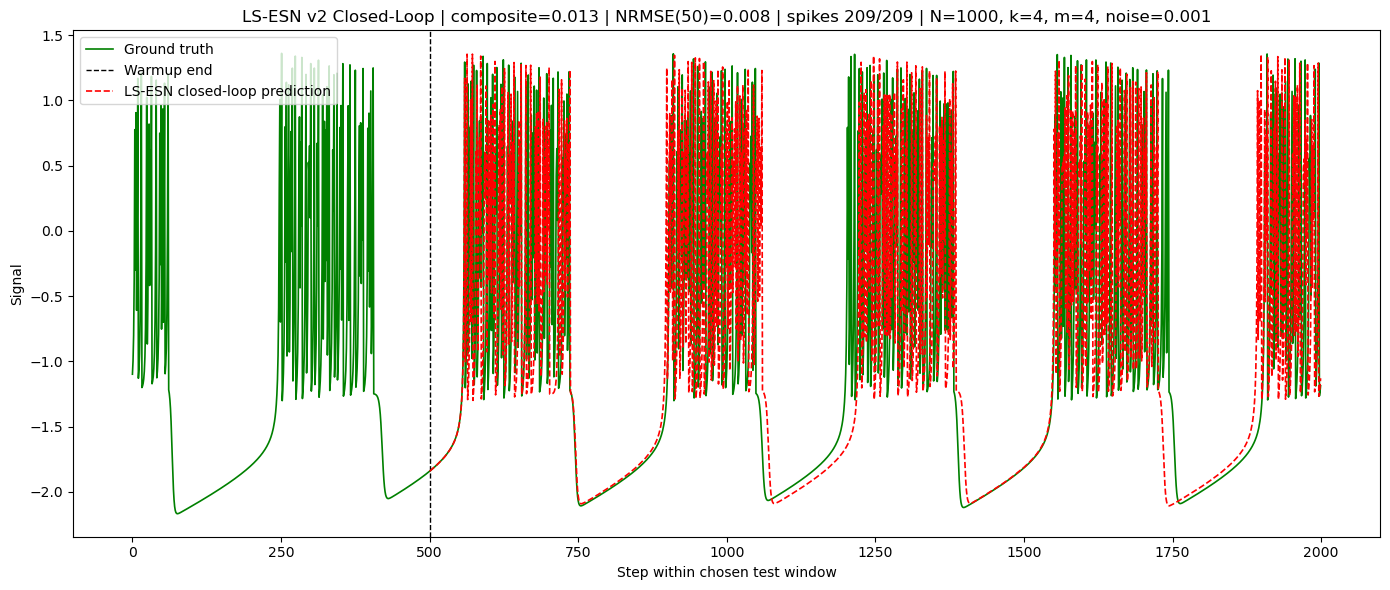

In [3]:

# ==========================================================
# REBUILD BEST MODEL (first seed)
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])
X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_model = LSESN(
    N=int(best_params["units"]),
    D=1,
    sr=best_params["sr"],
    lr_long=best_params["lr_long"],
    lr_typ=best_params["lr_typ"],
    lr_short=best_params["lr_short"],
    input_scaling=best_params["input_scaling"],
    connectivity=best_params["reservoir_connectivity"],
    k=best_params["k"],
    m=best_params["m"],
    ridge=best_params["regression"],
    noise_sigma=best_params["noise_sigma"],
    seed=SEEDS[0],
)
best_model.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])
preds_best_scaled = best_model.closed_loop(
    X_test_best[:best_params["test_warmup"]],
    n_steps=best_pred_len,
)
Y_pred_best = inverse_transform_array(preds_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(
    Y_test_best[best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len],
    best_scaler,
).ravel()

# Metrics in original scale
mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse_full = rmse / np.std(Y_true_best)
short = min(SHORT_HORIZON, len(Y_true_best))
nrmse_short = np.sqrt(np.mean((Y_true_best[:short] - Y_pred_best[:short]) ** 2)) / np.std(Y_true_best[:short])
n_true_spikes = count_spikes(Y_true_best, threshold=SPIKE_THRESHOLD)
n_pred_spikes = count_spikes(Y_pred_best, threshold=SPIKE_THRESHOLD)

print("\nFinal best-model metrics (original scale, single seed):")
print(f"MSE (full)        : {mse:.10f}")
print(f"NRMSE (full)      : {nrmse_full:.6f}")
print(f"NRMSE (first {short}) : {nrmse_short:.6f}")
print(f"Spikes true       : {n_true_spikes}")
print(f"Spikes predicted  : {n_pred_spikes}")
print(f"Spike ratio       : {n_pred_spikes / max(n_true_spikes, 1):.3f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2,
)
ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end",
)
ax.plot(
    np.arange(best_params["test_warmup"], best_params["test_warmup"] + best_pred_len),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="LS-ESN closed-loop prediction",
)
ax.set_title(
    f"LS-ESN v2 Closed-Loop | composite={best_score:.3f} | "
    f"NRMSE(50)={nrmse_short:.3f} | spikes {n_pred_spikes}/{n_true_spikes} | "
    f"N={int(best_params['units'])}, k={best_params['k']}, m={best_params['m']}, "
    f"noise={best_params['noise_sigma']}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()